**Define the Marketing Funnel (First & Most Important Step)**

Before touching Python, define funnel stages clearly.

A standard funnel:

Visitors → Leads → Qualified Leads → Customers

In [73]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("/content/bank-full.csv",sep=';')

# Quick inspection
df.head()
df.info()
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


# **2.1 Data Cleaning & Structuring**

In [74]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [75]:
# Example: drop rows with critical missing info
df = df.dropna(subset=["job", "education"])


In [76]:
df["is_visitor"] = 1
df["is_lead"] = np.where(df["contact"] != "unknown", 1, 0)
df["is_customer"] = np.where(df["y"] == "yes", 1, 0)


# **3.1 Funnel Volume Analysis**

In [77]:
funnel_counts = {
    "Visitors": df["is_visitor"].sum(),
    "Leads": df["is_lead"].sum(),
    "Customers": df["is_customer"].sum()
}

funnel_df = pd.DataFrame.from_dict(
    funnel_counts, orient="index", columns=["count"]
)

funnel_df


,count
Visitors,45211
Leads,32191
Customers,5289


# **4.1 Conversion Rate Analysis**

In [78]:
visitor_to_lead = funnel_counts["Leads"] / funnel_counts["Visitors"]
lead_to_customer = funnel_counts["Customers"] / funnel_counts["Leads"]
visitor_to_customer = funnel_counts["Customers"] / funnel_counts["Visitors"]

conversion_df = pd.DataFrame({
    "Metric": [
        "Visitor → Lead",
        "Lead → Customer",
        "Visitor → Customer"
    ],
    "Conversion Rate": [
        visitor_to_lead,
        lead_to_customer,
        visitor_to_customer
    ]
})

conversion_df


,Metric,Conversion Rate
0,Visitor → Lead,0.712017
1,Lead → Customer,0.164301
2,Visitor → Customer,0.116985


In [79]:

df_channel = df[df["contact"] != "unknown"]
channel_perf = (
    df_channel.groupby("contact")
    .agg(
        visitors=("is_visitor", "count"),
        leads=("is_lead", "sum"),
        customers=("is_customer", "sum")
    )
)
channel_perf["lead_conversion"] = channel_perf["leads"] / channel_perf["visitors"]
channel_perf["customer_conversion"] = channel_perf["customers"] / channel_perf["leads"]

channel_perf.sort_values("customer_conversion", ascending=False)


,visitors,leads,customers,lead_conversion,customer_conversion
contact,,,,,
cellular,29285,29285,4369,1.0,0.149189
telephone,2906,2906,390,1.0,0.134205


In [80]:
channel_perf["drop_after_lead"] = (
    channel_perf["leads"] - channel_perf["customers"]
)

channel_perf[["drop_after_lead"]].sort_values(
    by="drop_after_lead", ascending=False
)


,drop_after_lead
contact,
cellular,24916
telephone,2516


In [81]:
df["date"] = pd.to_datetime(df["day"], errors="coerce")

monthly_trend = (
    df.groupby(df["date"].dt.month)
    .agg(customers=("is_customer", "sum"))
)

monthly_trend


,customers
date,
1,5289


# **Chart : Funnel Bar Chart**

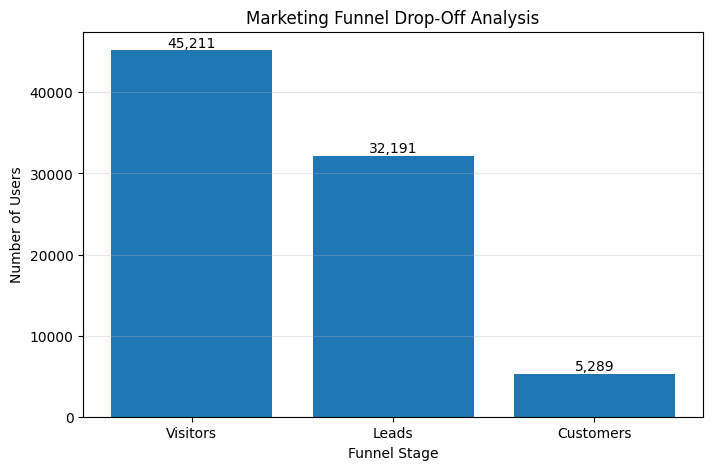

In [82]:
plt.figure(figsize=(8,5))
plt.bar(funnel_df.index, funnel_df["count"])
plt.title("Marketing Funnel Drop-Off Analysis")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Users")
plt.grid(axis="y", alpha=0.3)

for i, val in enumerate(funnel_df["count"]):
    plt.text(i, val, f"{val:,}", ha="center", va="bottom")

plt.show()


Immediate visibility of largest drop-off

Stakeholders instantly see funnel leakage

Perfect opening chart in any presentation

# **Chart : Conversion Rate Visualization**

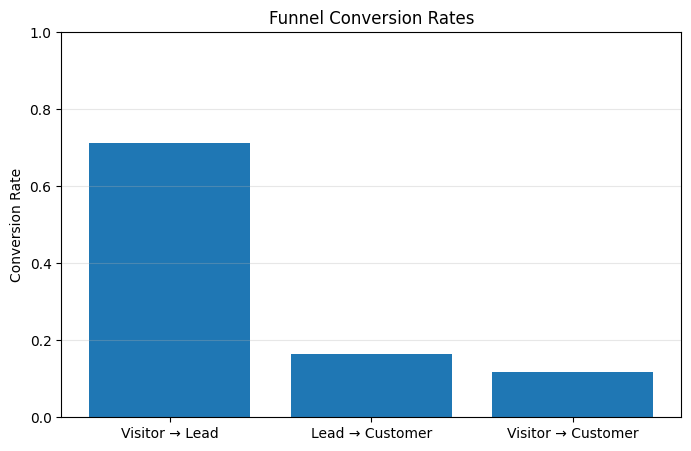

In [83]:
plt.figure(figsize=(8,5))
plt.bar(conversion_df["Metric"], conversion_df["Conversion Rate"])
plt.title("Funnel Conversion Rates")
plt.ylabel("Conversion Rate")
plt.ylim(0,1)
plt.grid(axis="y", alpha=0.3)
plt.show()


💡 Insight:

Identifies weakest funnel transition

Helps prioritize optimization efforts

Excellent for KPI reviews

# **Chart : Channel-wise Funnel Performance**

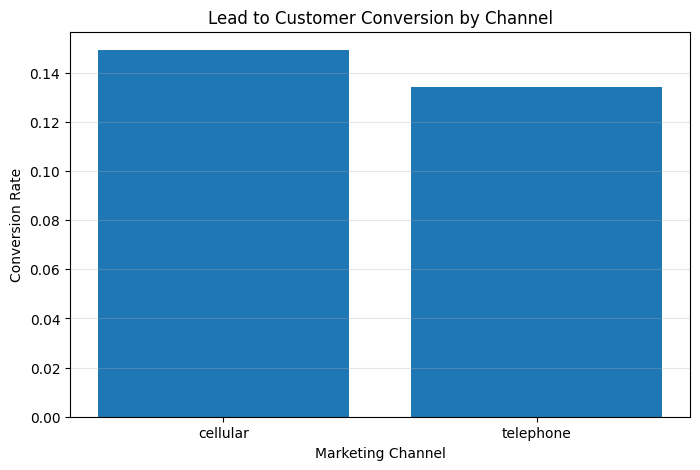

In [84]:
plt.figure(figsize=(8,5))
plt.bar(channel_perf.index, channel_perf["customer_conversion"])
plt.title("Lead to Customer Conversion by Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Conversion Rate")
plt.grid(axis="y", alpha=0.3)
plt.show()


💡 Insight:

Shows lead quality, not just volume

Channels with fewer leads but higher conversion stand out

Used to reallocate marketing budget

# **Chart: Channel Drop-Off Analysis**

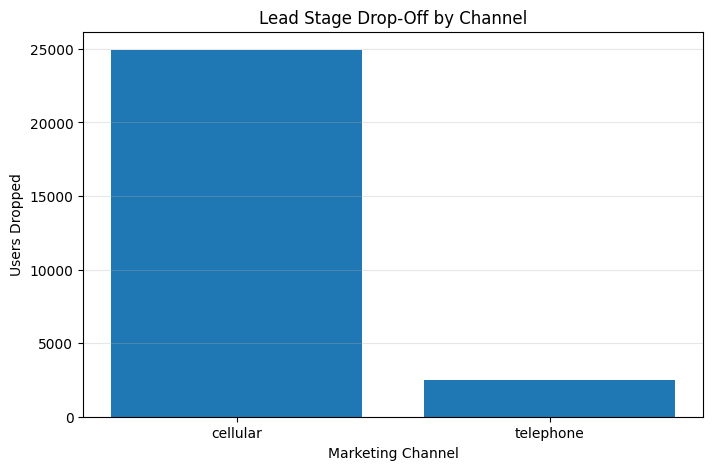

In [85]:
channel_perf["drop_after_lead"] = channel_perf["leads"] - channel_perf["customers"]

plt.figure(figsize=(8,5))
plt.bar(channel_perf.index, channel_perf["drop_after_lead"])
plt.title("Lead Stage Drop-Off by Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Users Dropped")
plt.grid(axis="y", alpha=0.3)
plt.show()


💡 Insight:

Identifies channels generating low-intent leads

Strong input for campaign refinement

Often used by sales + marketing jointly

# **Chart: Channel × Funnel Stage Comparison**

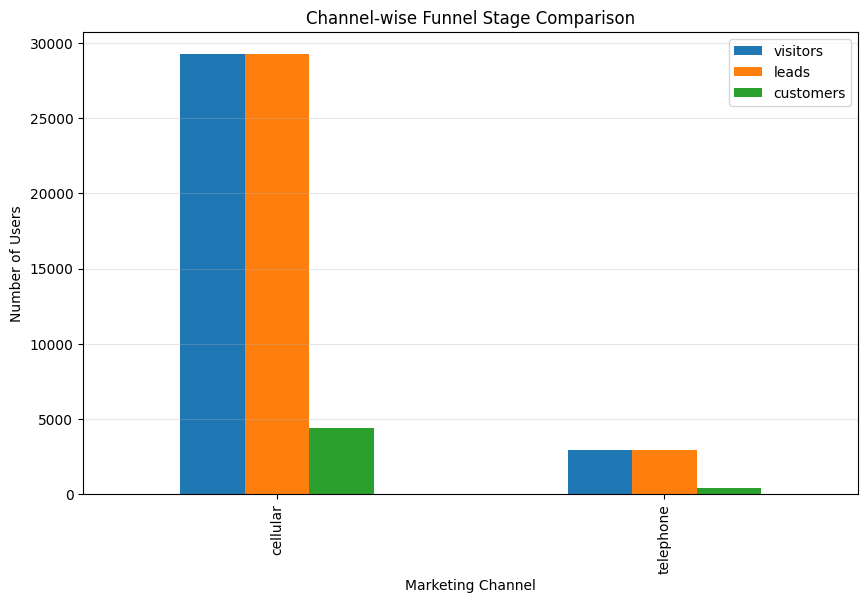

In [86]:
channel_perf[["visitors", "leads", "customers"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Channel-wise Funnel Stage Comparison")
plt.xlabel("Marketing Channel")
plt.ylabel("Number of Users")
plt.grid(axis="y", alpha=0.3)
plt.show()


# **Chart : Monthly Conversion Trend**

In [87]:
df["date"] = pd.to_datetime(
    df["day"].astype(str) + "-" + df["month"],
    format="%d-%b",
    errors="coerce"
)


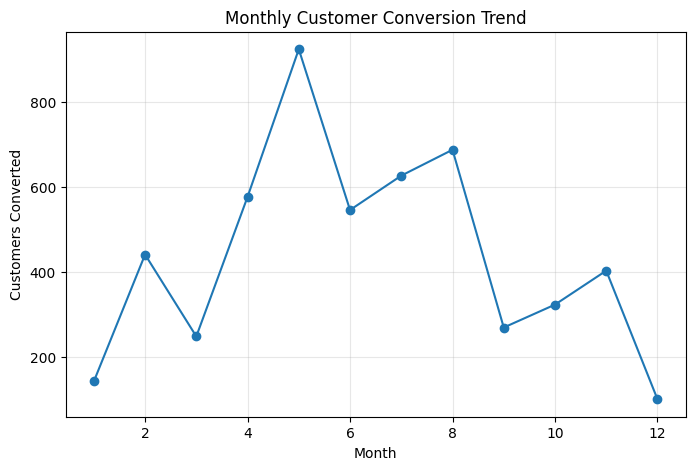

In [88]:
monthly_trend = (
    df.groupby(df["date"].dt.month)
      .agg(customers=("is_customer", "sum"))
)

plt.figure(figsize=(8,5))
plt.plot(monthly_trend.index, monthly_trend["customers"], marker="o")
plt.title("Monthly Customer Conversion Trend")
plt.xlabel("Month")
plt.ylabel("Customers Converted")
plt.grid(alpha=0.3)
plt.show()


# **Chart : Channel-wise Conversion Heatmap**

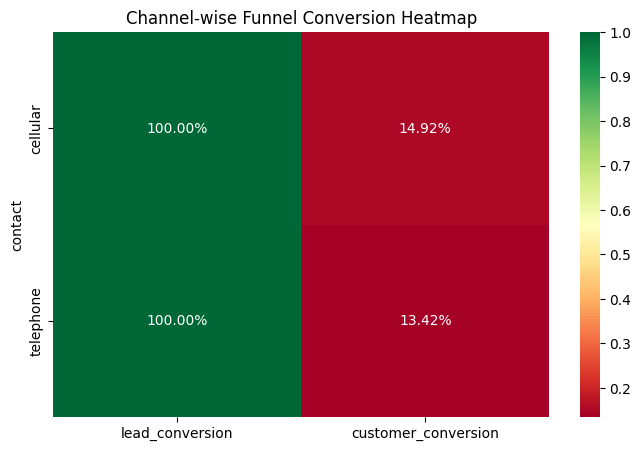

In [89]:
channel_stage_matrix = channel_perf[[
    "lead_conversion",
    "customer_conversion"
]]

plt.figure(figsize=(8,5))
sns.heatmap(channel_stage_matrix, annot=True, fmt=".2%", cmap="RdYlGn")
plt.title("Channel-wise Funnel Conversion Heatmap")
plt.show()


# **Chart: Pareto Analysis of Lead-to-Customer Drop-offs by Channel**

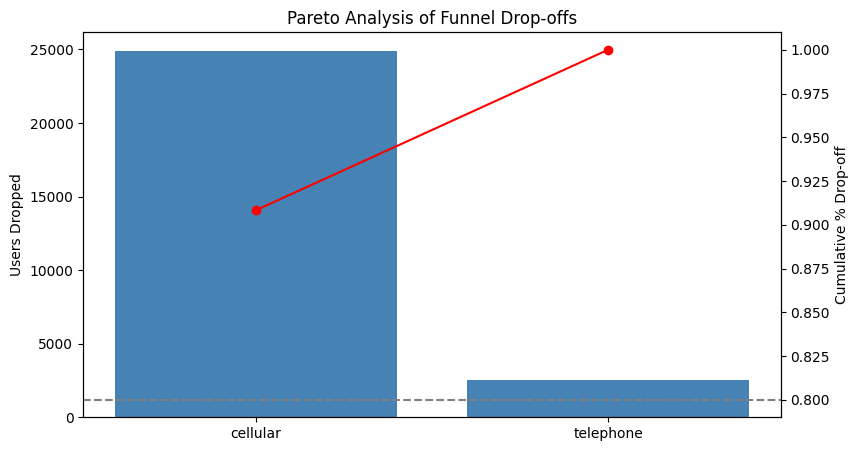

In [90]:
dropoffs = channel_perf["leads"] - channel_perf["customers"]
dropoffs = dropoffs.sort_values(ascending=False)

cum_pct = dropoffs.cumsum() / dropoffs.sum()

fig, ax1 = plt.subplots(figsize=(9,5))

ax1.bar(dropoffs.index, dropoffs, color="steelblue")
ax2 = ax1.twinx()
ax2.plot(dropoffs.index, cum_pct, color="red", marker="o")

ax1.set_ylabel("Users Dropped")
ax2.set_ylabel("Cumulative % Drop-off")
ax2.axhline(0.8, color="gray", linestyle="--")

plt.title("Pareto Analysis of Funnel Drop-offs")
plt.xticks(rotation=45)
plt.show()


# **Chart : Segmentation Analysis (Age Group)**

/tmp/ipython-input-3823454042.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



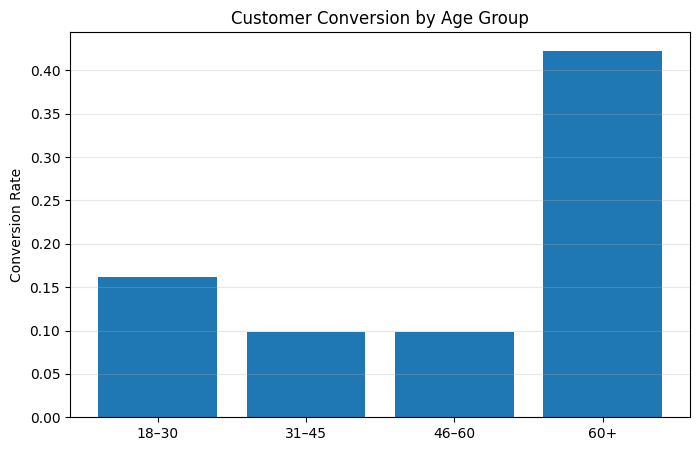

In [91]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[18,30,45,60,100],
    labels=["18–30","31–45","46–60","60+"]
)

age_perf = df.groupby("age_group")["is_customer"].mean()

plt.figure(figsize=(8,5))
plt.bar(age_perf.index.astype(str), age_perf.values)
plt.title("Customer Conversion by Age Group")
plt.ylabel("Conversion Rate")
plt.grid(axis="y", alpha=0.3)
plt.show()
